In [ ]:
# Import torch
import torch
from torch import nn

print(torch.__version__)

# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

2.10.0+cpu


'cpu'

In [ ]:
from requests.sessions import Request
# 1. Get data
from pathlib import Path
import zipfile
import requests

data_path = Path("data/")
image_path = data_path / "fried_rice_chicken_curry_dumplings_donuts30_percent"

if image_path.is_dir():
  print(f"{image_path} exists")
else:
  print(f"Creating... {image_path} directory.")
  image_path.mkdir(exist_ok=True,parents=True)
  with open(data_path/"fried_rice_chicken_curry_dumplings_donuts30_percent.zip","wb") as f:
    request = requests.get("https://github.com/AvisarBhandari/Ml/raw/main/Custom%20data/data/fried_rice_chicken_curry_dumplings_donuts30_percent.zip")
    print("Downloading data...")
    f.write(request.content)
  with zipfile.ZipFile(data_path/"fried_rice_chicken_curry_dumplings_donuts30_percent.zip",'r') as zip_ref:
    print("Unzipping file...")
    zip_ref.extractall(image_path)


Creating... data/fried_rice_chicken_curry_dumplings_donuts30_percent directory.
Unzipping file...


In [ ]:
# 2. Become one with the data
import os
def walk_through_dir(dir_path):
  """Walks through dir_path returning file counts of its contents."""
  for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

walk_through_dir(image_path)

There are 2 directories and 0 images in 'data/fried_rice_chicken_curry_dumplings_donuts30_percent'.
There are 4 directories and 0 images in 'data/fried_rice_chicken_curry_dumplings_donuts30_percent/test'.
There are 0 directories and 63 images in 'data/fried_rice_chicken_curry_dumplings_donuts30_percent/test/fried_rice'.
There are 0 directories and 72 images in 'data/fried_rice_chicken_curry_dumplings_donuts30_percent/test/chicken_curry'.
There are 0 directories and 82 images in 'data/fried_rice_chicken_curry_dumplings_donuts30_percent/test/dumplings'.
There are 0 directories and 83 images in 'data/fried_rice_chicken_curry_dumplings_donuts30_percent/test/donuts'.
There are 4 directories and 0 images in 'data/fried_rice_chicken_curry_dumplings_donuts30_percent/train'.
There are 0 directories and 213 images in 'data/fried_rice_chicken_curry_dumplings_donuts30_percent/train/fried_rice'.
There are 0 directories and 224 images in 'data/fried_rice_chicken_curry_dumplings_donuts30_percent/trai

In [ ]:
# Setup train and testing paths
train_dir = image_path / "train"
test_dir = image_path / "test"
train_dir , test_dir

(PosixPath('data/fried_rice_chicken_curry_dumplings_donuts30_percent/train'),
 PosixPath('data/fried_rice_chicken_curry_dumplings_donuts30_percent/test'))

Random image path: data/fried_rice_chicken_curry_dumplings_donuts30_percent/test/donuts/1156729.jpg
Image class: donuts
Image height: 512
Image width: 512


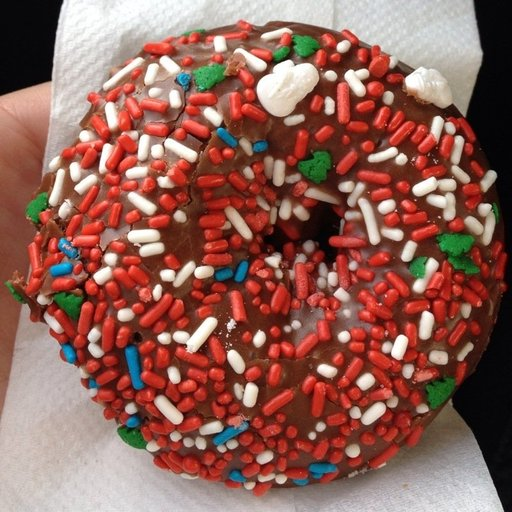

In [ ]:
# Visualize an image
import random
from PIL import Image
# set a seed
random.seed(42)
# get all the image path
image_path_list = list(image_path.glob("*/*/*.jpg"))
# get rangom image path
random_image_path = random.choice(image_path_list)
# get class from the path
image_class = random_image_path.parent.stem
img = Image.open(random_image_path)
# 5. Print metadata
print(f"Random image path: {random_image_path}")
print(f"Image class: {image_class}")
print(f"Image height: {img.height}")
print(f"Image width: {img.width}")
img

Text(0.5, 1.0, 'Image class: donuts | shape: (512, 512, 3)')

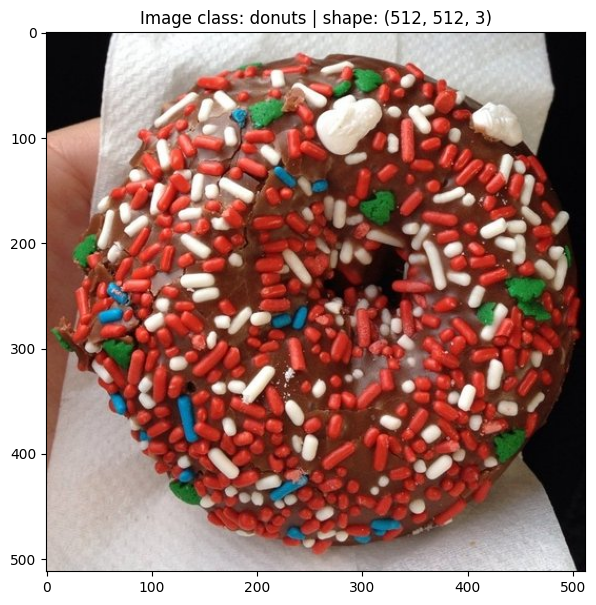

In [ ]:
# Do the image visualization with matplotlib
import numpy as np
import matplotlib.pyplot as plt
# turn image into array
image_array = np.asarray(img)
# plot image
plt.figure(figsize=(12,7))
plt.imshow(image_array)
plt.title(f"Image class: {image_class} | shape: {image_array.shape}")

In [ ]:
# Write transform for turning images into tensors
from torch.utils.data import DataLoader
from torchvision import transforms, datasets
train_transform = transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    transforms.ToTensor()
])
test_transform =  transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.ToTensor()
])

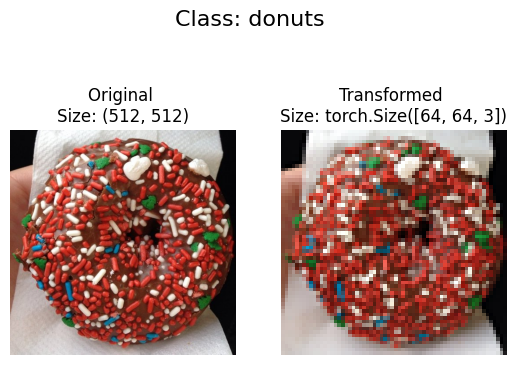

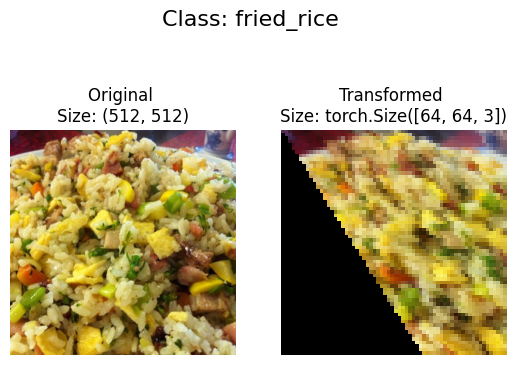

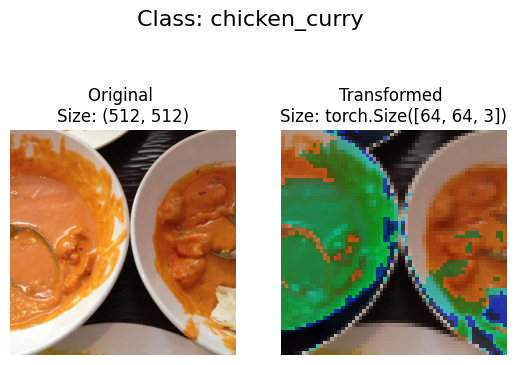

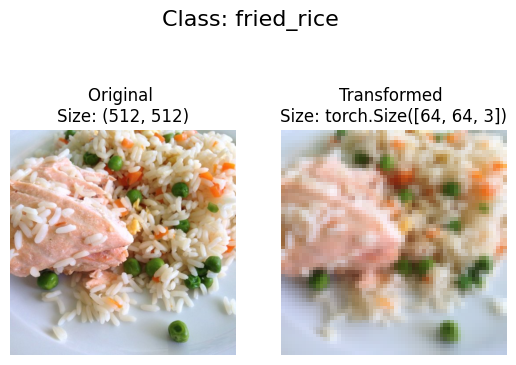

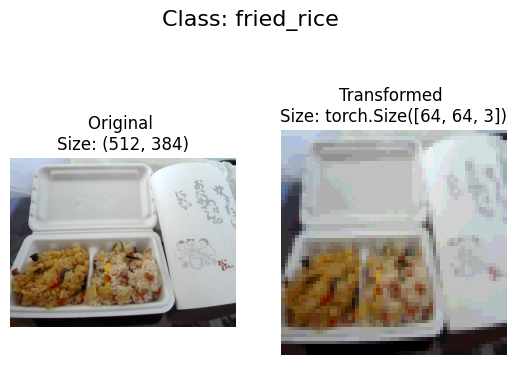

In [ ]:
# Write a function to plot transformed images
def plot_transformed_images(image_paths, transform, n=3, seed=42):
    """Plots a series of random images from image_paths.

    Will open n image paths from image_paths, transform them
    with transform and plot them side by side.

    Args:
        image_paths (list): List of target image paths.
        transform (PyTorch Transforms): Transforms to apply to images.
        n (int, optional): Number of images to plot. Defaults to 3.
        seed (int, optional): Random seed for the random generator. Defaults to 42.
    """
    random.seed(seed)
    random_image_paths = random.sample(image_paths, k=n)
    for image_path in random_image_paths:
        with Image.open(image_path) as f:
            fig, ax = plt.subplots(1, 2)
            ax[0].imshow(f)
            ax[0].set_title(f"Original \nSize: {f.size}")
            ax[0].axis("off")

            # Transform and plot image
            # Note: permute() will change shape of image to suit matplotlib
            # (PyTorch default is [C, H, W] but Matplotlib is [H, W, C])
            transformed_image = transform(f).permute(1, 2, 0)
            ax[1].imshow(transformed_image)
            ax[1].set_title(f"Transformed \nSize: {transformed_image.shape}")
            ax[1].axis("off")

            fig.suptitle(f"Class: {image_path.parent.stem}", fontsize=16)

plot_transformed_images(image_path_list,
                        transform=train_transform,
                        n=5)


### Load image data using `ImageFolder`

In [ ]:
# Use ImageFolder to create dataset(s)
train_data = datasets.ImageFolder(root=train_dir,
                                  transform=train_transform)
test_data = datasets.ImageFolder(root=test_dir,
                                 transform=train_transform)

In [ ]:
# Get class names as a list
class_names = train_data.classes
class_names

['chicken_curry', 'donuts', 'dumplings', 'fried_rice']

In [ ]:
# Can also get class names as a dict
class_dict = train_data.class_to_idx
class_dict

{'chicken_curry': 0, 'donuts': 1, 'dumplings': 2, 'fried_rice': 3}

In [ ]:
# Check the lengths of each dataset
len(train_data), len(test_data)

(900, 300)

In [ ]:
# Turn train and test Datasets into DataLoaders
import os
from torch.utils.data import DataLoader
BATCH_SIZE = 32
NUM_WORKER = os.cpu_count()
train_dataloader = DataLoader(dataset=train_data,
                              batch_size=BATCH_SIZE,
                              shuffle=True,
                              num_workers=NUM_WORKER)
test_dataloader = DataLoader(dataset=test_data,
                             batch_size=BATCH_SIZE,
                             num_workers=NUM_WORKER)
train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7e22fdc8bbf0>,
 <torch.utils.data.dataloader.DataLoader at 0x7e22fdbb50a0>)

In [ ]:
train_dataloader.batch_size,len(train_dataloader)

(32, 29)

In [ ]:
class TinyVGG(nn.Module):
  def __init__(self,input_shapes,hidden_unit,output_shapes):
    super().__init__()
    self.conv2d_block_1 = nn.Sequential(
        nn.Conv2d(in_channels=input_shapes , out_channels=hidden_unit, kernel_size=3, padding=1),
        nn.BatchNorm2d(hidden_unit),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_unit, out_channels=hidden_unit, kernel_size=3, padding=1),
        nn.BatchNorm2d(hidden_unit),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2)
    )
    self.conv2d_block_2 = nn.Sequential(
        nn.Conv2d(in_channels=hidden_unit, out_channels=hidden_unit, kernel_size=3, padding=1),
        nn.BatchNorm2d(hidden_unit),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_unit, out_channels=hidden_unit, kernel_size=3, padding=1),
        nn.BatchNorm2d(hidden_unit),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2)
    )
    self.classifier = nn.Sequential(
        nn.AdaptiveAvgPool2d((1, 1)),
        nn.Flatten(),
        nn.Dropout(p=0.5),
        nn.Linear(in_features=hidden_unit, out_features=output_shapes)

    )
  def forward(self, x:torch.Tensor):
    return self.classifier(self.conv2d_block_2(self.conv2d_block_1(x)))
model_0 = TinyVGG(input_shapes=3, hidden_unit=10 , output_shapes=len(class_names)).to(device)
model_0

TinyVGG(
  (conv2d_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(10, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(10, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2d_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(10, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(10, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    

In [ ]:
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               ):

  # Put the model in train mode
  model.train()

  # Setup train loss and train accuracy values
  train_loss, train_acc = 0, 0

  # Loop through data loader and data batches
  for batch, (x, y) in enumerate(train_dataloader):
    # Send data to target device
    x, y = x.to(device), y.to(device)
    # 1. Forward pass
    train_logits = model(x)
    # 2. Calculate and accumulate loss
    loss = loss_fn(train_logits,y)
    train_loss +=loss.item()
    # 3. Optimizer zero grad
    optimizer.zero_grad()
    # 4. Loss backward
    loss.backward()
    # 5. Optimizer step
    optimizer.step()
    # Calculate and accumualte accuracy metric across all batches
    y_pred_class = torch.argmax(torch.softmax(train_logits,dim=1),dim=1)
    train_acc += (y_pred_class == y).sum().item()/len(train_logits)

  # Adjust metrics to get average loss and average accuracy per batch
  train_loss = train_loss/len(dataloader)
  train_acc = train_acc/len(dataloader)
  return train_loss, train_acc


In [ ]:
def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module):

  # Put model in eval mode
  model.eval()

  # Setup the test loss and test accuracy values
  test_loss, test_acc = 0, 0

  # Turn on inference context manager
  with torch.inference_mode():
    # Loop through DataLoader batches
    for batch,(x,y) in enumerate(dataloader):
      # Send data to target device
      x, y = x.to(device), y.to(device)
      # 1. Forward pass
      test_logits = model(x)
      # 2. Calculuate and accumulate loss
      loss = loss_fn(test_logits, y)
      test_loss += loss.item()
      # Calculate and accumulate accuracy
      y_pred_class = torch.argmax(torch.softmax(test_logits,dim=1),dim=1)
      test_acc += (y_pred_class == y ).sum().item() / len(test_logits)
  # Adjust metrics to get average loss and accuracy per batch
  test_loss = test_loss / len(dataloader)
  test_acc = test_acc / len(dataloader)
  return test_loss, test_acc


In [ ]:
def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          epochs: int = 5,
          scheduler: torch.optim.lr_scheduler = None): # Add this

  results = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

  for epoch in tqdm(range(epochs)):
    # Update the learning rate if a scheduler is provided

    train_loss, train_acc = train_step(model=model,
                                      dataloader=train_dataloader,
                                      loss_fn=loss_fn,
                                      optimizer=optimizer)
    test_loss, test_acc = test_step(model=model,
                                  dataloader=test_dataloader,
                                  loss_fn=loss_fn)
    # Update the learning rate if a scheduler is provided
    if scheduler:
        scheduler.step()


    print(f"Epoch: {epoch+1} | train_loss: {train_loss:.4f} | train_acc: {train_acc:.4f} | test_loss: {test_loss:.4f} | test_acc: {test_acc:.4f} | LR: {optimizer.param_groups[0]['lr']:.6f}")

    results["train_loss"].append(train_loss)
    results["train_acc"].append(train_acc)
    results["test_loss"].append(test_loss)
    results["test_acc"].append(test_acc)

  return results


In [ ]:
from typing import Dict, List
def plot_loss_curves(results: Dict[str, List[float]]):
    """Plots training curves of a results dictionary.

    Args:
        results (dict): dictionary containing list of values, e.g.
            {"train_loss": [...],
             "train_acc": [...],
             "test_loss": [...],
             "test_acc": [...]}
    """

    # Get the loss values of the results dictionary (training and test)
    loss = results['train_loss']
    test_loss = results['test_loss']

    # Get the accuracy values of the results dictionary (training and test)
    accuracy = results['train_acc']
    test_accuracy = results['test_acc']

    # Figure out how many epochs there were
    epochs = range(len(results['train_loss']))

    # Setup a plot
    plt.figure(figsize=(15, 7))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, label='train_loss')
    plt.plot(epochs, test_loss, label='test_loss')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, accuracy, label='train_accuracy')
    plt.plot(epochs, test_accuracy, label='test_accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.legend();

In [ ]:
from tqdm.auto import tqdm
# Train for 5 epochs
torch.manual_seed(42)
torch.cuda.manual_seed(42)
NUM_EPOCHS=5

five_epochs_model_0 = TinyVGG(input_shapes=3, hidden_unit=20 , output_shapes=len(class_names)).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(five_epochs_model_0.parameters(),
                             lr=0.001,
                             weight_decay=1e-2)

# Start the timer
from timeit import default_timer as timer
start_time = timer()

# Train model_0
model_0_results_5_epochs = train(model=five_epochs_model_0,
                        train_dataloader=train_dataloader,
                        test_dataloader=test_dataloader,
                        optimizer=optimizer,
                        loss_fn=loss_fn,
                        epochs=NUM_EPOCHS)

# End the timer and print out how long it took
end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.4395 | train_acc: 0.2812 | test_loss: 1.4183 | test_acc: 0.2521 | LR: 0.001000
Epoch: 2 | train_loss: 1.3423 | train_acc: 0.3459 | test_loss: 1.3130 | test_acc: 0.3906 | LR: 0.001000
Epoch: 3 | train_loss: 1.2955 | train_acc: 0.3610 | test_loss: 1.2978 | test_acc: 0.3927 | LR: 0.001000
Epoch: 4 | train_loss: 1.3101 | train_acc: 0.3631 | test_loss: 1.2884 | test_acc: 0.4333 | LR: 0.001000
Epoch: 5 | train_loss: 1.3115 | train_acc: 0.3718 | test_loss: 1.2875 | test_acc: 0.4167 | LR: 0.001000
Total training time: 62.193 seconds


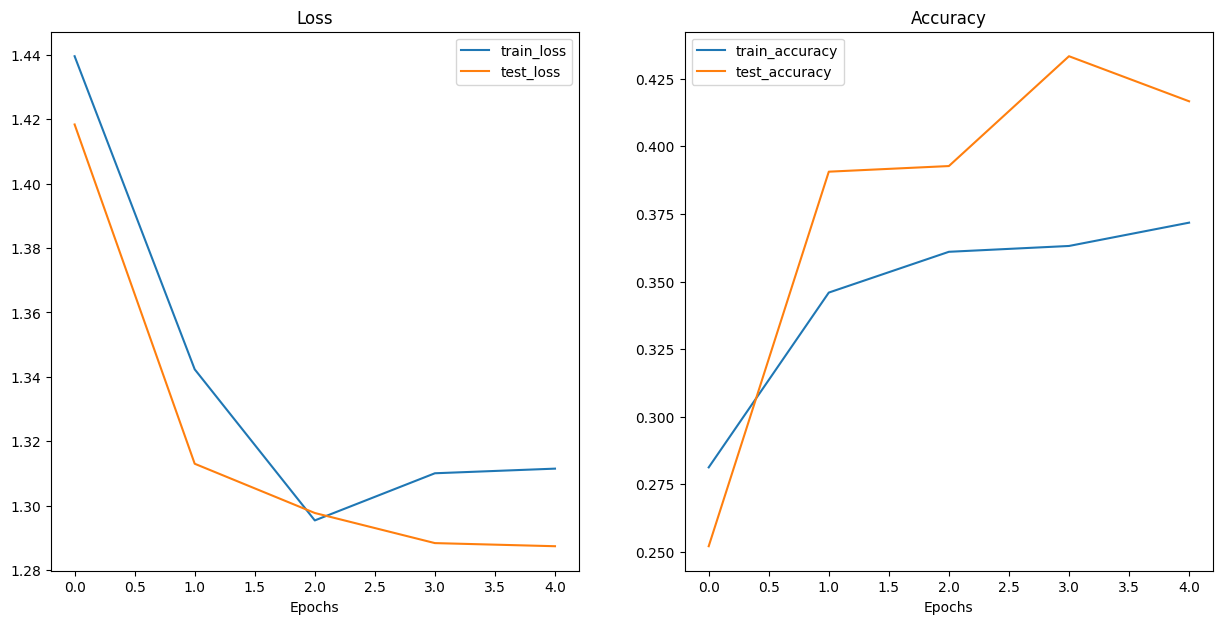

In [ ]:
plot_loss_curves(model_0_results_5_epochs)

In [ ]:
test_model_0 = TinyVGG(input_shapes=3, hidden_unit=20 , output_shapes=len(class_names)).to(device)
loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.Adam(test_model_0.parameters(),
                             lr=0.001,
                             weight_decay=1e-1)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer,step_size=20, gamma=0.1)

In [ ]:
from tqdm.auto import tqdm
torch.manual_seed(42)
torch.cuda.manual_seed(42)
NUM_EPOCHS=50
# Start the timer
from timeit import default_timer as timer
start_time = timer()

# Train model_0
model_0_results_50_epochs = train(model=test_model_0,
                        train_dataloader=train_dataloader,
                        test_dataloader=test_dataloader,
                        optimizer=optimizer,
                        loss_fn=loss_fn,
                        epochs=NUM_EPOCHS,
                                   scheduler=scheduler)

# End the timer and print out how long it took
end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/50 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.3954 | train_acc: 0.3287 | test_loss: 1.3777 | test_acc: 0.2437 | LR: 0.001000
Epoch: 2 | train_loss: 1.3397 | train_acc: 0.3782 | test_loss: 1.3643 | test_acc: 0.2844 | LR: 0.001000
Epoch: 3 | train_loss: 1.3340 | train_acc: 0.3772 | test_loss: 1.3175 | test_acc: 0.4594 | LR: 0.001000
Epoch: 4 | train_loss: 1.3308 | train_acc: 0.3761 | test_loss: 1.3338 | test_acc: 0.3281 | LR: 0.001000
Epoch: 5 | train_loss: 1.3305 | train_acc: 0.3998 | test_loss: 1.3341 | test_acc: 0.3760 | LR: 0.001000
Epoch: 6 | train_loss: 1.3232 | train_acc: 0.3922 | test_loss: 1.3245 | test_acc: 0.4177 | LR: 0.001000
Epoch: 7 | train_loss: 1.3121 | train_acc: 0.3901 | test_loss: 1.3623 | test_acc: 0.3354 | LR: 0.001000
Epoch: 8 | train_loss: 1.3228 | train_acc: 0.4106 | test_loss: 1.3310 | test_acc: 0.4073 | LR: 0.001000
Epoch: 9 | train_loss: 1.3284 | train_acc: 0.3793 | test_loss: 1.3509 | test_acc: 0.3302 | LR: 0.001000
Epoch: 10 | train_loss: 1.3239 | train_acc: 0.3944 | test_loss: 

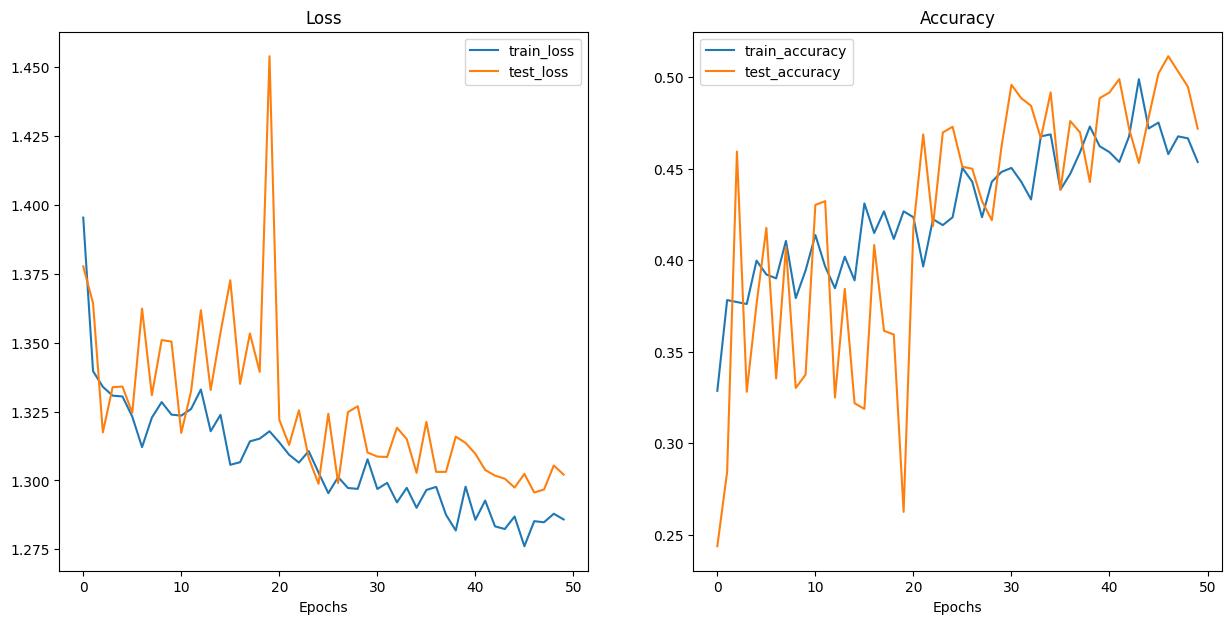

In [ ]:
plot_loss_curves(model_0_results_50_epochs)

In [ ]:
# makeing 5 epoch prediction
from tqdm.auto import tqdm
y_preds = []
five_epochs_model_0.eval()
with torch.inference_mode():
  for X, y in tqdm(test_dataloader, desc="Making predictions"):
    X,y = X.to(device) , y.to(device)
    y_logit=five_epochs_model_0(X)
    y_pred = torch.softmax(y_logit.squeeze(),dim=1).argmax(dim=1)
    y_preds.append(y_pred.cpu())

  # print(y_preds)
  y_pred_5_tensor = torch.cat(y_preds)
  y_pred_5_tensor[:5]

Making predictions:   0%|          | 0/10 [00:00<?, ?it/s]

In [ ]:
# makeing 50 epoch prediction
from tqdm.auto import tqdm
y_preds = []
test_model_0.eval()
with torch.inference_mode():
  for X, y in tqdm(test_dataloader, desc="Making predictions"):
    X,y = X.to(device) , y.to(device)
    y_logit=test_model_0(X)
    y_pred = torch.softmax(y_logit.squeeze(),dim=1).argmax(dim=1)
    y_preds.append(y_pred.cpu())

  # print(y_preds)
  y_pred_50_tensor = torch.cat(y_preds)
  y_pred_50_tensor[:5]

Making predictions:   0%|          | 0/10 [00:00<?, ?it/s]

In [ ]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 19.7 MB/s eta 0:00:00


In [ ]:
# Making a confusion matrix for further prediction evaluation
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix
import numpy as np
def plot_confusion_mat(pred_tensor):
    # Setup confusion matrix instance
    confmat = ConfusionMatrix(num_classes=len(class_names), task="multiclass")
    # compare predictions to targets resnet
    confmat_tensor = confmat(preds = pred_tensor,
                            target = torch.tensor(test_data.targets))
    # 3. Plot the confusion matrix
    fig, ax = plot_confusion_matrix(
      conf_mat=confmat_tensor.numpy(),
      class_names=class_names,
      figsize=(10,7)
    )

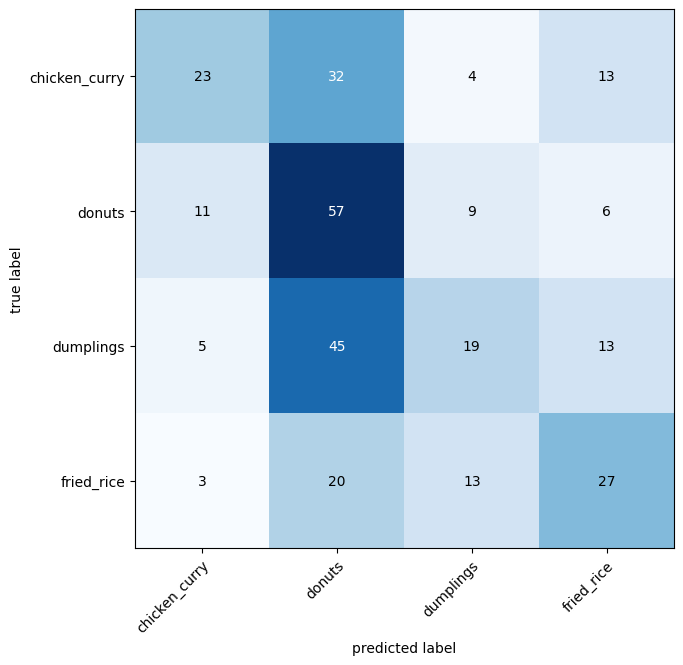

In [ ]:
plot_confusion_mat(pred_tensor=y_pred_5_tensor)

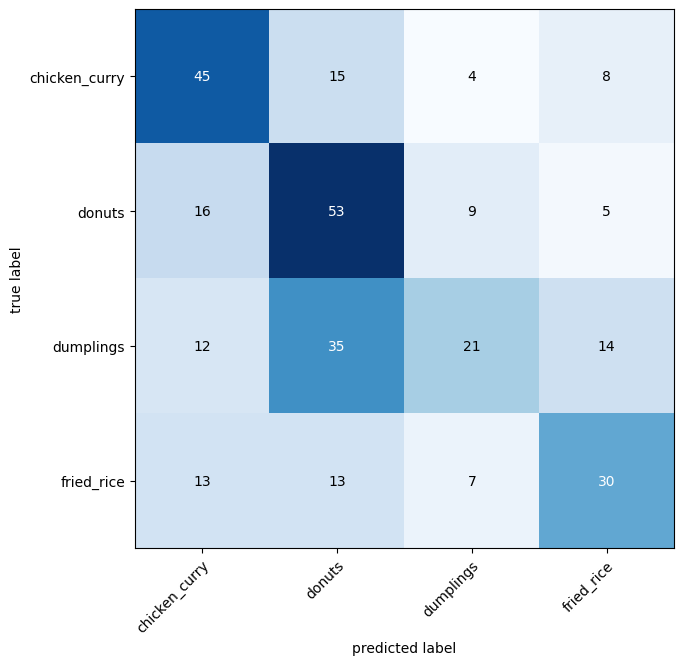

In [ ]:
plot_confusion_mat(y_pred_50_tensor)

In [ ]:
import torchvision.models as models

# 1. Load pre-trained ResNet18
# Use 'weights' instead of 'pretrained=True' for newer torchvision versions
model_resnet = models.resnet18(weights='IMAGENET1K_V1',progress=True).to(device)

# 2. Freeze all base layers (feature extractor)
for param in model_resnet.parameters():
    param.requires_grad = False

# 3. Replace the final fully connected layer (fc)
# model_resnet.fc.in_features is 512 for ResNet18
model_resnet.fc = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(in_features=model_resnet.fc.in_features, out_features=len(class_names))
).to(device)

# 4. Optimizer: Only update the parameters of the new head
optimizer = torch.optim.Adam(model_resnet.fc.parameters(), lr=0.001)

# 5. Train as usual
resnet_results = train(model=model_resnet,
                      train_dataloader=train_dataloader,
                      test_dataloader=test_dataloader,
                      optimizer=optimizer,
                      loss_fn=nn.CrossEntropyLoss(),
                      epochs=50)


  0%|          | 0/50 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.5633 | train_acc: 0.3168 | test_loss: 1.3489 | test_acc: 0.4021 | LR: 0.001000
Epoch: 2 | train_loss: 1.3262 | train_acc: 0.4353 | test_loss: 1.2516 | test_acc: 0.5031 | LR: 0.001000
Epoch: 3 | train_loss: 1.2049 | train_acc: 0.5011 | test_loss: 1.1562 | test_acc: 0.5260 | LR: 0.001000
Epoch: 4 | train_loss: 1.1104 | train_acc: 0.5216 | test_loss: 1.0605 | test_acc: 0.5844 | LR: 0.001000
Epoch: 5 | train_loss: 1.0758 | train_acc: 0.5539 | test_loss: 0.9927 | test_acc: 0.5865 | LR: 0.001000
Epoch: 6 | train_loss: 1.0316 | train_acc: 0.5948 | test_loss: 1.0852 | test_acc: 0.5490 | LR: 0.001000
Epoch: 7 | train_loss: 1.0604 | train_acc: 0.5647 | test_loss: 0.9916 | test_acc: 0.6104 | LR: 0.001000
Epoch: 8 | train_loss: 1.0389 | train_acc: 0.5657 | test_loss: 0.9398 | test_acc: 0.6354 | LR: 0.001000
Epoch: 9 | train_loss: 0.9994 | train_acc: 0.5970 | test_loss: 0.9364 | test_acc: 0.6146 | LR: 0.001000
Epoch: 10 | train_loss: 0.9795 | train_acc: 0.5959 | test_loss: 

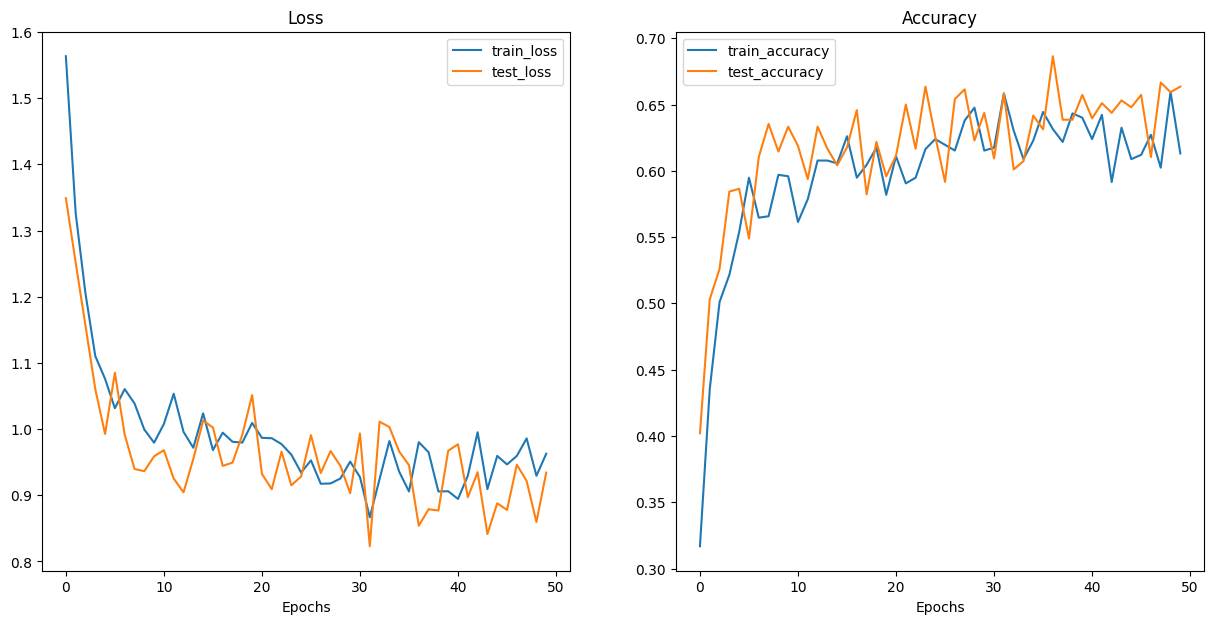

In [ ]:
plot_loss_curves(resnet_results)

In [ ]:
# makeing resnet prediction
from tqdm.auto import tqdm
y_preds = []
model_resnet.eval()
with torch.inference_mode():
  for X, y in tqdm(test_dataloader, desc="Making predictions"):
    X,y = X.to(device) , y.to(device)
    y_logit=model_resnet(X)
    y_pred = torch.softmax(y_logit.squeeze(),dim=1).argmax(dim=1)
    y_preds.append(y_pred.cpu())

  # print(y_preds)
  y_pred_resnet_tensor = torch.cat(y_preds)
  y_pred_resnet_tensor[:5]

Making predictions:   0%|          | 0/10 [00:00<?, ?it/s]

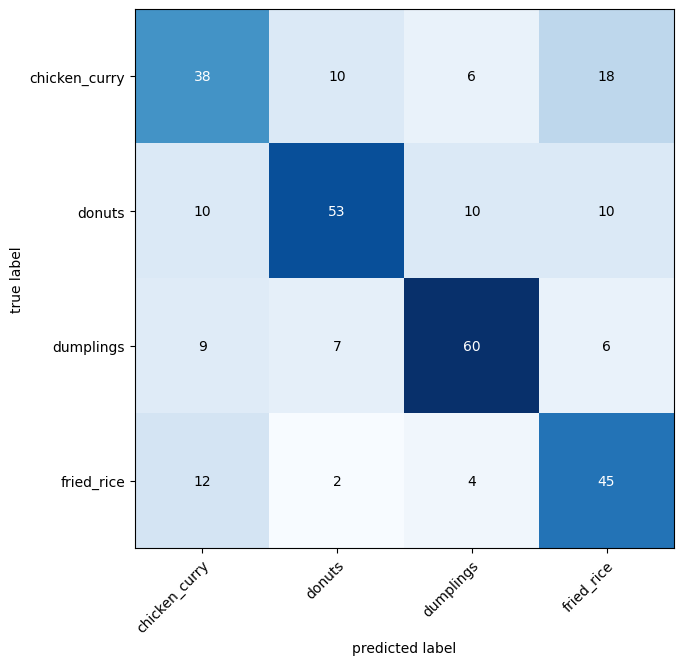

In [ ]:
plot_confusion_mat(y_pred_resnet_tensor)

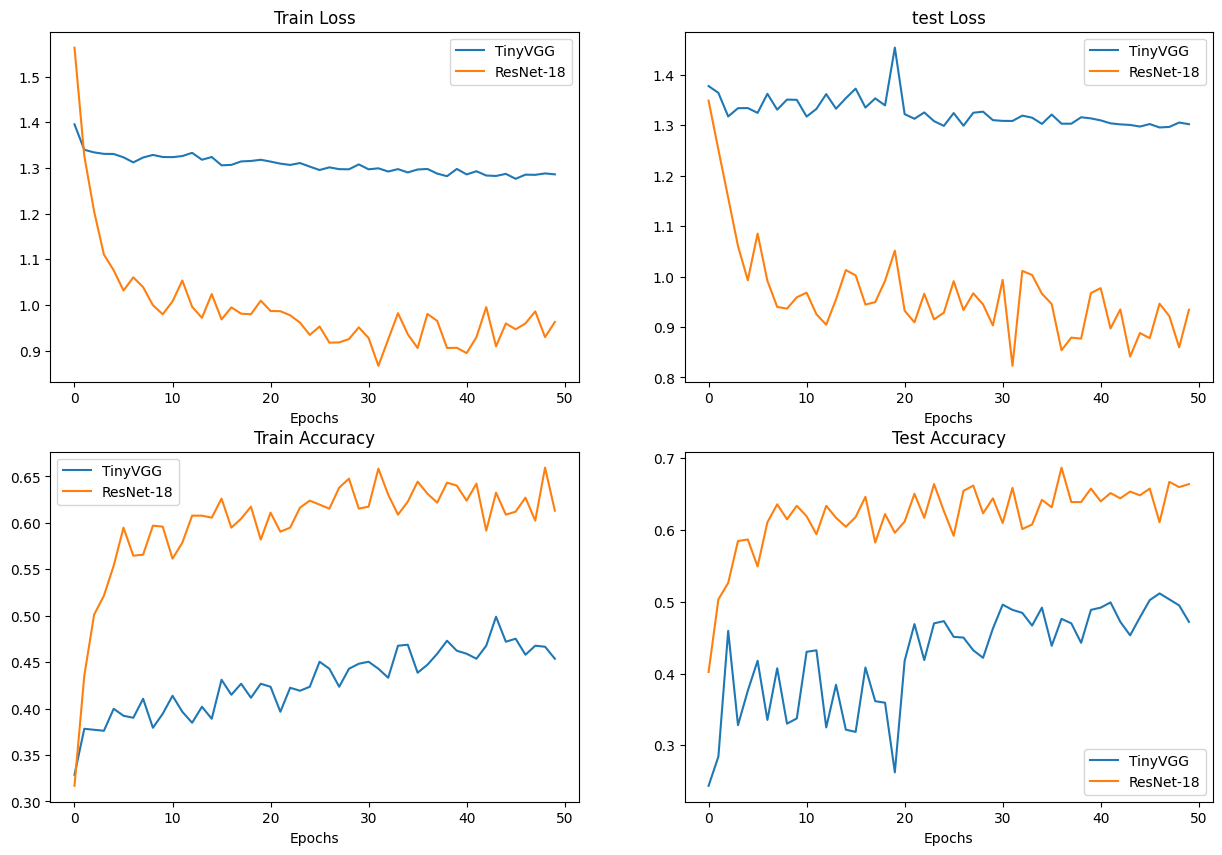

In [ ]:
plt.figure(figsize=(15,10))

epochs = range(50)

# plot train loss
plt.subplot(2,2,1)
plt.plot(epochs,model_0_results_50_epochs["train_loss"],label="TinyVGG")
plt.plot(epochs,resnet_results["train_loss"],label="ResNet-18")
plt.title("Train Loss")
plt.xlabel("Epochs")
plt.legend()
# plot test loss
plt.subplot(2,2,2)
plt.plot(epochs,model_0_results_50_epochs["test_loss"],label="TinyVGG")
plt.plot(epochs,resnet_results["test_loss"],label="ResNet-18")
plt.title("test Loss")
plt.xlabel("Epochs")
plt.legend()
# plot train accuracy
plt.subplot(2,2,3)
plt.plot(epochs,model_0_results_50_epochs["train_acc"],label="TinyVGG")
plt.plot(epochs,resnet_results["train_acc"],label="ResNet-18")
plt.title("Train Accuracy")
plt.xlabel("Epochs")
plt.legend()
# plot test accuracy
plt.subplot(2,2,4)
plt.plot(epochs,model_0_results_50_epochs["test_acc"],label="TinyVGG")
plt.plot(epochs,resnet_results["test_acc"],label="ResNet-18")
plt.title("Test Accuracy")
plt.xlabel("Epochs")
plt.legend()

In [ ]:
torch.save(obj=test_model_0.state_dict,f="models/TinyVGG_50_epoch.pth")
torch.save(obj=model_resnet.state_dict,f="models/resnet_50_epoch.pth")